In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch

from dvfm.data import sample_moons
from dvfm.flow_matching import flow_matching_loss
from dvfm.models import MLP

torch.manual_seed(0)

data = sample_moons(50_000, seed=0)
model = MLP()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [3]:
batch_size = 512
num_steps = 5000
losses = []

for step in range(num_steps):
    # Random batch of real data
    idx = torch.randint(0, len(data), (batch_size,))
    x1 = data[idx]

    # Compute loss and update the network
    loss = flow_matching_loss(model, x1)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if step % 500 == 0:
        print(f"step {step:5d} | loss {loss.item():.4f}")

step     0 | loss 1.9288
step   500 | loss 1.4137
step  1000 | loss 1.3755
step  1500 | loss 1.4553
step  2000 | loss 1.4140
step  2500 | loss 1.5083
step  3000 | loss 1.4454
step  3500 | loss 1.4797
step  4000 | loss 1.6130
step  4500 | loss 1.4810


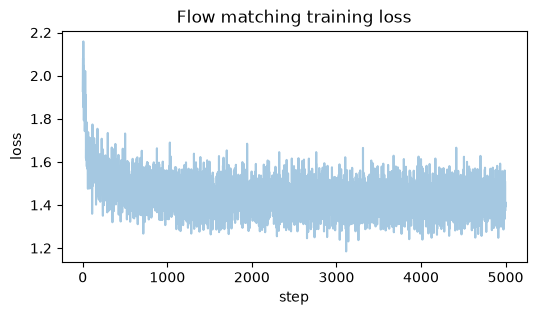

In [4]:
plt.figure(figsize=(6, 3))
plt.plot(losses, alpha=0.4)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Flow matching training loss")
plt.show()

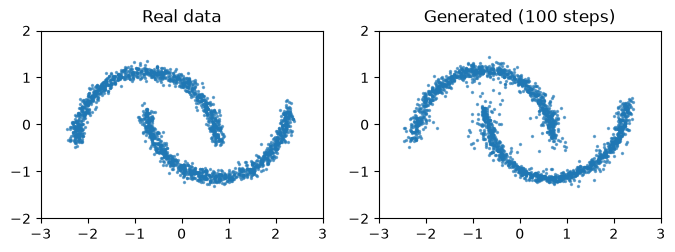

In [6]:
from dvfm.flow_matching import sample

model.eval()
generated = sample(model, 2000, num_steps=100)
real = data[torch.randperm(len(data))[:2000]]  # 2000 random real points

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, points, title in [(axes[0], real, "Real data"), (axes[1], generated, "Generated (100 steps)")]:
    ax.scatter(points[:, 0], points[:, 1], s=2, alpha=0.6)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-2, 2)
plt.show()

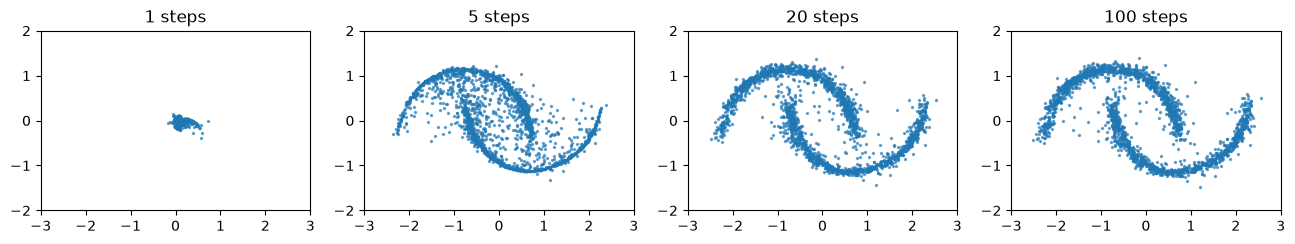

In [8]:
from pathlib import Path

steps_list = [1, 5, 20, 100]

fig, axes = plt.subplots(1, len(steps_list), figsize=(16, 4))
for ax, steps in zip(axes, steps_list):
    torch.manual_seed(0)  # same starting noise for every run, for a fair comparison
    points = sample(model, 2000, num_steps=steps)
    ax.scatter(points[:, 0], points[:, 1], s=2, alpha=0.6)
    ax.set_title(f"{steps} steps")
    ax.set_aspect("equal")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-2, 2)

Path("../assets").mkdir(exist_ok=True)  # create the assets folder if it doesn't exist
plt.savefig("../assets/fm_steps_comparison.png", dpi=150, bbox_inches="tight")
plt.show()